* In this notebook we are going to implement the modelling part that predicts with data up to minute x, the probability of injury until the end of the session

### Importing Packages

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from itertools import product

### Data Loading

In [2]:
model_df = pd.read_csv('D:/PhD EMP/2020/model_df.csv').drop("Unnamed: 0", axis=1)

# NON-PERSONALIZED APPROACH

### Splitting in Train and Test Sets

In [3]:
X = model_df.drop(columns=["injury"])
y = model_df["injury"]
groups = model_df["session_id"]

* We dont want data leakage, so we actually split based on session_id....If we don't, then we will end up with the same session minutes in train and test, so this is going to end up in data leakage

In [4]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups))

In [5]:
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

### Leakage Test

In [6]:
train_sessions = set(model_df.iloc[train_idx]["session_id"])
test_sessions = set(model_df.iloc[test_idx]["session_id"])

train_sessions.intersection(test_sessions)

set()

* This practically means that no session id is included both in the train and test set, which means that we have no actual leakage

### Class Imbalance Test

In [7]:
print("Train injury rate:", y_train.mean())
print("Test injury rate:", y_test.mean())

Train injury rate: 0.007354442602469016
Test injury rate: 0.010245319357181195


### Dropping Unnecessary Columns

In [8]:
drop_cols = ["session_id", "player_name", "date", "minute"]

X_train = X_train.drop(columns=drop_cols, errors="ignore")
X_test = X_test.drop(columns=drop_cols, errors="ignore")

### Scaling

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Modelling

The model estimates the probability that a given session will result in an injury, 
based on information accumulated up to minute 𝑥
x, enabling dynamic risk assessment as the session progresses.

Η μοντελοποίηση πραγματοποιήθηκε σε minute-level δεδομένα, όπου κάθε παρατήρηση αντιστοιχεί σε έναν παίκτη σε συγκεκριμένο session και minute x με στόχο την εκτίμηση της πιθανότητας το session να καταλήξει σε τραυματισμό. 

Για την αποφυγή data leakage, εφαρμόστηκε split με βάση το session_id χρησιμοποιώντας GroupShuffleSplit, διασφαλίζοντας ότι όλα τα minutes του ίδιου session ανήκουν αποκλειστικά είτε στο training είτε στο test set. 

Το μοντέλο εκπαιδεύτηκε στο training set και αξιολογήθηκε αποκλειστικά στο test set, ενώ οι προβλεπόμενες πιθανότητες (predict_proba) αντιστοιχίστηκαν απευθείας στα αντίστοιχα observations μέσω index alignment, επιτρέποντας τη σύνδεση κάθε πρόβλεψης με το αντίστοιχο minute, session και παίκτη χωρίς ανάγκη για merging. 

Η αξιολόγηση βασίστηκε κυρίως στις μετρικές ROC-AUC και PR-AUC, όπου η πρώτη αποτυπώνει τη διακριτική ικανότητα του μοντέλου (ικανότητα κατάταξης injury έναντι non-injury περιπτώσεων), ενώ η δεύτερη είναι καταλληλότερη για σπάνια γεγονότα και αποτυπώνει την απόδοση στο positive class. Επιπλέον, αναλύθηκαν precision και recall για διαφορετικά thresholds, καθώς η χρήση σταθερού threshold (π.χ. 0.5) δεν είναι κατάλληλη σε highly imbalanced settings.

Αντί για binary classification, δόθηκε έμφαση σε risk stratification, δηλαδή στην ικανότητα του μοντέλου να εντοπίζει υποσύνολα υψηλού κινδύνου (π.χ. top 1–10% observations) με σημαντικά αυξημένη πιθανότητα τραυματισμού σε σχέση με το baseline.

Για τη βελτιστοποίηση του μοντέλου πραγματοποιείται tuning κυρίως στο classification threshold και στις παραμέτρους του εκάστοτε αλγορίθμου (π.χ. regularization), με στόχο τη βελτίωση του precision–recall trade-off.

Σε όρους απόδοσης, ένα μοντέλο θεωρείται αποδεκτό όταν επιτυγχάνει ROC-AUC > 0.75–0.80 και PR-AUC σημαντικά υψηλότερο από το baseline (≥2–3 φορές), ενώ η πρακτική του αξία τεκμηριώνεται μέσω της ικανότητάς του να εντοπίζει high-risk observations με πολλαπλάσιο injury rate σε σχέση με τον συνολικό πληθυσμό.

### Metrics Definition
* ROC-AUC (Receiver Operating Characteristic – Area Under Curve): Μετρά τη συνολική ικανότητα του μοντέλου να διαχωρίζει sessions που καταλήγουν σε τραυματισμό από αυτά που δεν καταλήγουν, ανεξαρτήτως threshold. Μια τιμή ~0.77 σημαίνει ότι το μοντέλο κατατάσσει σωστά ένα τυχαίο injury observation πάνω από ένα non-injury περίπου στο 77% των περιπτώσεων, αλλά δεν παρέχει πληροφορία για το πόσο καλά εντοπίζονται τα πιο υψηλού κινδύνου cases.

* PR-AUC (Precision–Recall Area Under Curve): Είναι πιο κατάλληλο για προβλήματα με έντονο class imbalance (όπως το injury prediction), καθώς εστιάζει στην απόδοση του μοντέλου στα θετικά περιστατικά. Δείχνει πόσο καλά ισορροπεί το μοντέλο μεταξύ precision (πόσα από τα predicted injuries είναι όντως injury) και recall (πόσα injury εντοπίζονται), με τιμές σημαντικά πάνω από το baseline (~1%) να υποδεικνύουν ουσιαστική βελτίωση έναντι τυχαίας πρόβλεψης.

* Top-k Injury Rate (Top 1%, 5%, 10%): Μετρά την πρακτική αξία του μοντέλου ως εργαλείο ιεράρχησης κινδύνου. Συγκεκριμένα, εξετάζει το ποσοστό τραυματισμών μέσα στα k% πιο “επικίνδυνα” predictions (με τα υψηλότερα scores). Για παράδειγμα, Top 1% = 8% σημαίνει ότι μέσα στο 1% των πιο risky observations, περίπου 8% καταλήγουν σε τραυματισμό, δηλαδή ~8× υψηλότερο από το baseline, κάτι που υποδεικνύει ισχυρή ικανότητα εντοπισμού high-risk καταστάσεων.

* Συνδυαστική ερμηνεία: Τα ROC-AUC και PR-AUC αξιολογούν τη συνολική (global) απόδοση του μοντέλου, ενώ τα top-k metrics αποτυπώνουν την ικανότητά του να εντοπίζει τα πιο κρίσιμα υψηλού κινδύνου περιστατικά. Στο συγκεκριμένο πρόβλημα, τα top-k αποτελέσματα αποτελούν το βασικό κριτήριο επιτυχίας, καθώς αντικατοπτρίζουν άμεσα τη χρησιμότητα του μοντέλου σε real-world εφαρμογές risk monitoring.

### Logistic Regression

In [10]:
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_prob)

pr_auc = average_precision_score(y_test, y_pred_prob)

from sklearn.metrics import classification_report

y_pred = (y_pred_prob > 0.5).astype(int)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print(classification_report(y_test, y_pred))

ROC-AUC: 0.8158066606106859
PR-AUC: 0.0294682403803219
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     62697
           1       0.03      0.18      0.05       649

    accuracy                           0.92     63346
   macro avg       0.51      0.56      0.50     63346
weighted avg       0.98      0.92      0.95     63346



In [11]:
df_eval = pd.DataFrame({
    "prob": y_pred_prob,
    "y": y_test
})

for p in [0.01, 0.05, 0.1]:
    top = df_eval.sort_values("prob", ascending=False).head(int(p * len(df_eval)))
    print(f"Top {int(p*100)}% injury rate:", top["y"].mean())

Top 1% injury rate: 0.0
Top 5% injury rate: 0.01894537417113988
Top 10% injury rate: 0.03347016103568046


### XGBOOST

In [12]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train) / y_train.sum()),  # important for imbalance
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_prob_xgb = xgb_model.predict_proba(
    X_test)[:, 1]

In [13]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc_xgb = roc_auc_score(y_test, y_pred_prob_xgb)
pr_auc_xgb = average_precision_score(y_test, y_pred_prob_xgb)

print("XGB ROC-AUC:", roc_auc_xgb)
print("XGB PR-AUC:", pr_auc_xgb)

XGB ROC-AUC: 0.7993272754355314
XGB PR-AUC: 0.05442050865904267


In [14]:
df_eval_xgb = pd.DataFrame({
    "prob": y_pred_prob_xgb,
    "y": y_test
})

for p in [0.01, 0.05, 0.1]:
    top = df_eval_xgb.sort_values("prob", ascending=False).head(int(p * len(df_eval_xgb)))
    print(f"Top {int(p*100)}% injury rate:", top["y"].mean())

Top 1% injury rate: 0.052132701421800945
Top 5% injury rate: 0.07451847173981686
Top 10% injury rate: 0.061414587938111775


### Tuning XGBOOST

In [15]:
param_grid = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1]
}

results = []

for n_est, depth, lr in product(
    param_grid["n_estimators"],
    param_grid["max_depth"],
    param_grid["learning_rate"]
):

    model = XGBClassifier(
        n_estimators=n_est,
        max_depth=depth,
        learning_rate=lr,
        scale_pos_weight=(len(y_train) / y_train.sum()),
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    roc = roc_auc_score(y_test, y_prob)
    pr = average_precision_score(y_test, y_prob)

    # Top-k
    df_eval = pd.DataFrame({"prob": y_prob, "y": y_test})

    def top_k_rate(df, p):
        top = df.sort_values("prob", ascending=False).head(int(p * len(df)))
        return top["y"].mean()

    top1 = top_k_rate(df_eval, 0.01)
    top5 = top_k_rate(df_eval, 0.05)
    top10 = top_k_rate(df_eval, 0.10)

    results.append({
        "n_estimators": n_est,
        "max_depth": depth,
        "learning_rate": lr,
        "ROC_AUC": roc,
        "PR_AUC": pr,
        "Top1": top1,
        "Top5": top5,
        "Top10": top10
    })

df_tuning = pd.DataFrame(results)

df_tuning = df_tuning.sort_values("Top1", ascending=False)

* Best Model:
  
  * n_estimators	max_depth	learning_rate	ROC_AUC	    PR_AUC	     Top1	     Top5	     Top10
       200	       3	        0.03	    0.771125	0.055142	0.083728	0.065993	0.063309

* The final model was selected based on a balance between strong enrichment in high-risk observations (top-k performance) and overall stability, achieving approximately 8× higher injury rates in the top 1% of predictions.

In [16]:
xgb_model_tuned = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train) / y_train.sum()),  # important for imbalance
    random_state=42,
    n_jobs=-1
)

xgb_model_tuned.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

In [17]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_pred_prob = xgb_model_tuned.predict_proba(X_test_scaled)[:, 1]

roc_auc_xgb = roc_auc_score(y_test, y_pred_prob_xgb)
pr_auc_xgb = average_precision_score(y_test, y_pred_prob_xgb)
df_eval_xgb = pd.DataFrame({
    "prob": y_pred_prob_xgb,
    "y": y_test
})

print("XGB ROC-AUC:", roc_auc_xgb)
print("XGB PR-AUC:", pr_auc_xgb)
for p in [0.01, 0.05, 0.1]:
    top = df_eval_xgb.sort_values("prob", ascending=False).head(int(p * len(df_eval_xgb)))
    print(f"Top {int(p*100)}% injury rate:", top["y"].mean())


print("Test prevalence:", y_test.mean())
baseline = y_test.mean()

print("Lift Top1:", 0.052132701421800945 / baseline)
print("Lift Top5:", 0.07451847173981686 / baseline)
print("Lift Top10:", 0.061414587938111775 / baseline)

XGB ROC-AUC: 0.7993272754355314
XGB PR-AUC: 0.05442050865904267
Top 1% injury rate: 0.052132701421800945
Top 5% injury rate: 0.07451847173981686
Top 10% injury rate: 0.061414587938111775
Test prevalence: 0.010245319357181195
Lift Top1: 5.088440838621576
Lift Top5: 7.273416195424406
Lift Top10: 5.994404449195113


### Personalized Modelling Extension

In [18]:
# ============================================
# Personalized Temporal Modelling
# Same task: P(injury by end of session | data up to minute t)
# ============================================

import pandas as pd
import numpy as np

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

In [19]:
personal_df = model_df.copy()

personal_df["session_date"] = pd.to_datetime(
    personal_df["session_id"].str.split("_").str[-1]
)

personal_df["player_session_id"] = (
    personal_df["player_name"].astype(str)
    + "_"
    + personal_df["session_id"].astype(str)
)

personal_df = personal_df.sort_values(
    ["player_name", "session_date", "minute_idx"]
).reset_index(drop=True)

In [20]:
id_cols = [
    "session_id",
    "player_session_id",
    "player_name",
    "session_date",
    "minute_idx",
    "injury"
]

base_features = [
    col for col in personal_df.columns
    if col not in id_cols
]

print("Base features:", len(base_features))

Base features: 78


In [21]:
session_table = (
    personal_df[["player_name", "player_session_id", "session_date"]]
    .drop_duplicates()
    .sort_values(["player_name", "session_date"])
    .reset_index(drop=True)
)

session_counts = session_table.groupby("player_name")["player_session_id"].nunique()

min_sessions = 5
valid_players = session_counts[session_counts >= min_sessions].index

personal_df = personal_df[personal_df["player_name"].isin(valid_players)].copy()
session_table = session_table[session_table["player_name"].isin(valid_players)].copy()

train_sessions = []
test_sessions = []

train_frac = 0.4

for player, grp in session_table.groupby("player_name"):
    grp = grp.sort_values("session_date")
    split_idx = int(len(grp) * train_frac)

    train_sessions.extend(grp.iloc[:split_idx]["player_session_id"].tolist())
    test_sessions.extend(grp.iloc[split_idx:]["player_session_id"].tolist())

train_df = personal_df[personal_df["player_session_id"].isin(train_sessions)].copy()
test_df = personal_df[personal_df["player_session_id"].isin(test_sessions)].copy()

overlap = set(train_df["player_session_id"]).intersection(set(test_df["player_session_id"]))

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Overlap:", overlap)

print("Train injury sessions:", train_df.groupby("player_session_id")["injury"].max().sum())
print("Test injury sessions:", test_df.groupby("player_session_id")["injury"].max().sum())

Train rows: 145416
Test rows: 206525
Overlap: set()
Train injury sessions: 13
Test injury sessions: 11


In [22]:
player_stats = (
    train_df
    .groupby("player_name")[base_features]
    .agg(["mean", "std"])
)

player_stats.columns = [
    f"{col}_{stat}" for col, stat in player_stats.columns
]

print(player_stats.shape)

(47, 156)


In [23]:
def add_player_relative_features(df, player_stats, features):
    df_new = df.copy()

    for feat in features:
        mean_col = f"{feat}_mean"
        std_col = f"{feat}_std"

        means = df_new["player_name"].map(player_stats[mean_col])
        stds = df_new["player_name"].map(player_stats[std_col])

        df_new[f"{feat}_player_z"] = (
            (df_new[feat] - means) / (stds + 1e-6)
        )

    return df_new

In [24]:
train_personal = add_player_relative_features(
    train_df,
    player_stats,
    base_features
)

test_personal = add_player_relative_features(
    test_df,
    player_stats,
    base_features
)

train_personal = train_personal.fillna(0)
test_personal = test_personal.fillna(0)

In [25]:
drop_cols = [
    "injury",
    "session_id",
    "player_session_id",
    "player_name",
    "session_date",
    "minute_idx"
]

X_train_personal = train_personal.drop(columns=drop_cols, errors="ignore")
y_train_personal = train_personal["injury"]

X_test_personal = test_personal.drop(columns=drop_cols, errors="ignore")
y_test_personal = test_personal["injury"]

print(X_train_personal.shape)
print(X_test_personal.shape)

(145416, 156)
(206525, 156)


In [26]:
personal_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.03,
    scale_pos_weight=(len(y_train_personal) / y_train_personal.sum()),
    subsample=0.9,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

personal_model.fit(X_train_personal, y_train_personal)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

In [27]:
y_prob_personal = personal_model.predict_proba(X_test_personal)[:, 1]

print("Personalized ROC-AUC:", roc_auc_score(y_test_personal, y_prob_personal))
print("Personalized PR-AUC:", average_precision_score(y_test_personal, y_prob_personal))

df_eval_personal = pd.DataFrame({
    "prob": y_prob_personal,
    "y": y_test_personal
})

for p in [0.01, 0.05, 0.10]:
    top = (
        df_eval_personal
        .sort_values("prob", ascending=False)
        .head(int(p * len(df_eval_personal)))
    )
    print(f"Top {int(p*100)}% injury rate:", top["y"].mean())


print("Test prevalence:", y_test_personal.mean())
baseline_personal = y_test_personal.mean()

print("Lift Top1:", 0.052132701421800945 / baseline_personal)
print("Lift Top5:", 0.07451847173981686 / baseline_personal)
print("Lift Top10:", 0.061414587938111775 / baseline_personal)

Personalized ROC-AUC: 0.880747705328351
Personalized PR-AUC: 0.07835970808470773
Top 1% injury rate: 0.12445520581113802
Top 5% injury rate: 0.07495642068564788
Top 10% injury rate: 0.047453031183420494
Test prevalence: 0.006105798329500061
Lift Top1: 8.538228517951975
Lift Top5: 12.204541931852242
Lift Top10: 10.058404261632461


### ANALYSIS: PERSONALIZED AND NON-PERSONALIZED APPROACH

### NON-PERSONALIZED

### Risk evolution: injury vs non-injury

In [28]:
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
import numpy as np

drop_cols = ["injury", "session_id", "player_name", "date", "minute"]

X = model_df.drop(columns=drop_cols, errors="ignore")
y = model_df["injury"]
groups = model_df["session_id"]

gkf = GroupKFold(n_splits=5)

oof_preds = np.zeros(len(model_df))

for train_idx, val_idx in gkf.split(X, y, groups):

    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr = y.iloc[train_idx]

    model = XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.03,
        scale_pos_weight=(len(y_tr) / y_tr.sum()),
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_tr, y_tr)

    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

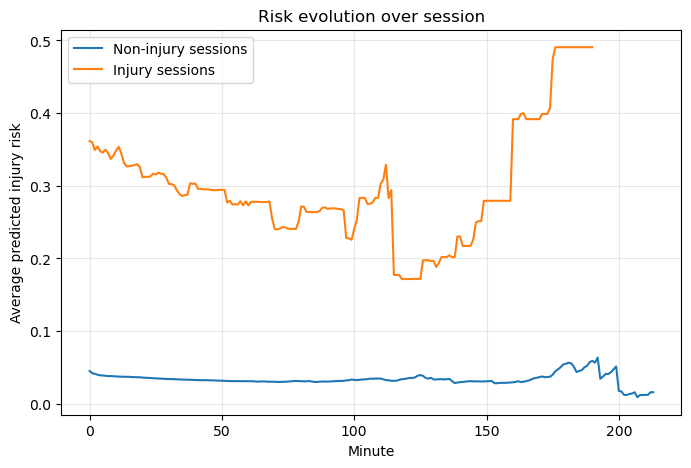

In [29]:
model_df["injury_risk"] = oof_preds

df_final = model_df[[
    "player_name",
    "session_id",
    "minute_idx",
    "injury",
    "injury_risk"
]].copy()

df_final = df_final.sort_values(
    ["player_name", "session_id", "minute_idx"]
).reset_index(drop=True)

risk_by_outcome = (
    df_final.groupby(["minute_idx", "injury"])["injury_risk"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

for label, grp in risk_by_outcome.groupby("injury"):
    name = "Injury sessions" if label == 1 else "Non-injury sessions"
    plt.plot(grp["minute_idx"], grp["injury_risk"], label=name)

plt.xlabel("Minute")
plt.ylabel("Average predicted injury risk")
plt.title("Risk evolution over session")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

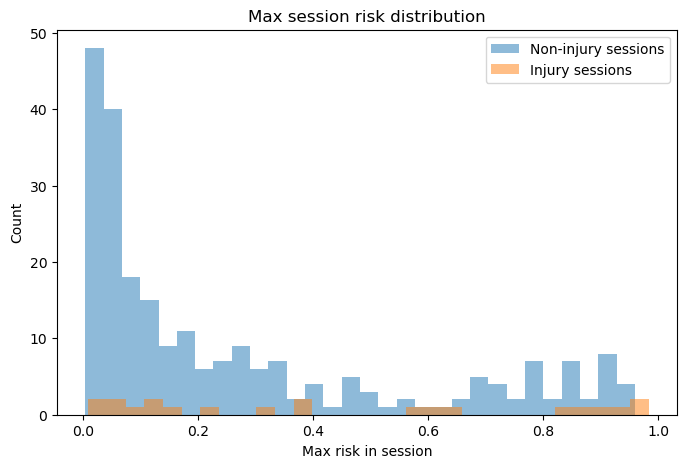

In [30]:
session_risk = (
    df_final.groupby(["session_id", "injury"])["injury_risk"]
    .max()
    .reset_index()
)

plt.figure(figsize=(8,5))

for label, grp in session_risk.groupby("injury"):
    name = "Injury sessions" if label == 1 else "Non-injury sessions"
    plt.hist(grp["injury_risk"], bins=30, alpha=0.5, label=name)

plt.xlabel("Max risk in session")
plt.ylabel("Count")
plt.title("Max session risk distribution")
plt.legend()
plt.show()

### PERSONALIZED

### Risk evolution: injury vs non-injury

In [31]:
# ============================================
# Personalized Risk Analysis
# Final Clean Version
# ============================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupKFold
from xgboost import XGBClassifier

# ============================================
# 1. OOF TRAIN PREDICTIONS
# ============================================

drop_cols = [
    "injury",
    "session_id",
    "player_session_id",
    "player_name",
    "session_date",
    "minute_idx"
]

X_personal = train_personal.drop(
    columns=drop_cols,
    errors="ignore"
)

y_personal = train_personal["injury"]

groups_personal = train_personal["player_session_id"]

gkf = GroupKFold(n_splits=5)

oof_preds_personal = np.zeros(len(train_personal))

for train_idx, val_idx in gkf.split(
    X_personal,
    y_personal,
    groups_personal
):

    X_tr = X_personal.iloc[train_idx]
    X_val = X_personal.iloc[val_idx]

    y_tr = y_personal.iloc[train_idx]

    model = XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.03,
        scale_pos_weight=(
            len(y_tr) / y_tr.sum()
        ),
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_tr, y_tr)

    oof_preds_personal[val_idx] = (
        model.predict_proba(X_val)[:, 1]
    )

# ============================================
# 2. TRAIN RISK DATAFRAME (OOF)
# ============================================

df_final_personal_train = train_personal[[
    "player_name",
    "player_session_id",
    "session_id",
    "session_date",
    "minute_idx",
    "injury"
]].copy()

df_final_personal_train["injury_risk"] = (
    oof_preds_personal
)

df_final_personal_train = (
    df_final_personal_train
    .sort_values([
        "player_name",
        "session_date",
        "minute_idx"
    ])
    .reset_index(drop=True)
)

# ============================================
# 3. TEST RISK DATAFRAME
# ============================================

df_final_personal_test = test_personal[[
    "player_name",
    "player_session_id",
    "session_id",
    "session_date",
    "minute_idx",
    "injury"
]].copy()

df_final_personal_test["injury_risk"] = (
    y_prob_personal
)

df_final_personal_test = (
    df_final_personal_test
    .sort_values([
        "player_name",
        "session_date",
        "minute_idx"
    ])
    .reset_index(drop=True)
)

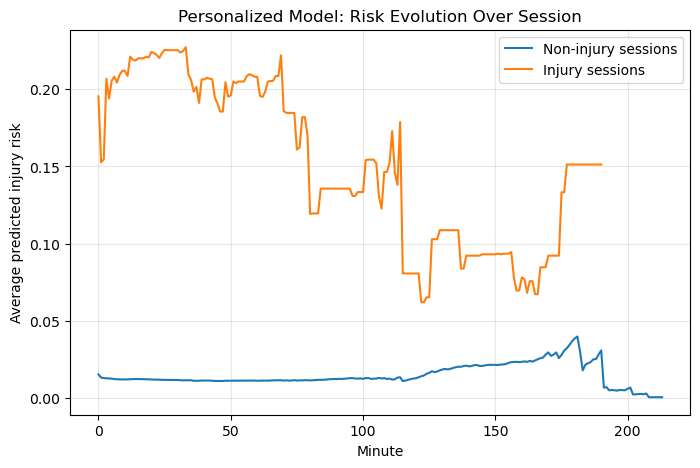

In [32]:
# ============================================
# 4. RISK EVOLUTION PLOT
# (USE TEST SET)
# ============================================

risk_by_outcome_personal = (
    df_final_personal_test
    .groupby([
        "minute_idx",
        "injury"
    ])["injury_risk"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

for label, grp in (
    risk_by_outcome_personal
    .groupby("injury")
):

    name = (
        "Injury sessions"
        if label == 1
        else "Non-injury sessions"
    )

    plt.plot(
        grp["minute_idx"],
        grp["injury_risk"],
        label=name
    )

plt.xlabel("Minute")
plt.ylabel("Average predicted injury risk")

plt.title(
    "Personalized Model: Risk Evolution Over Session"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

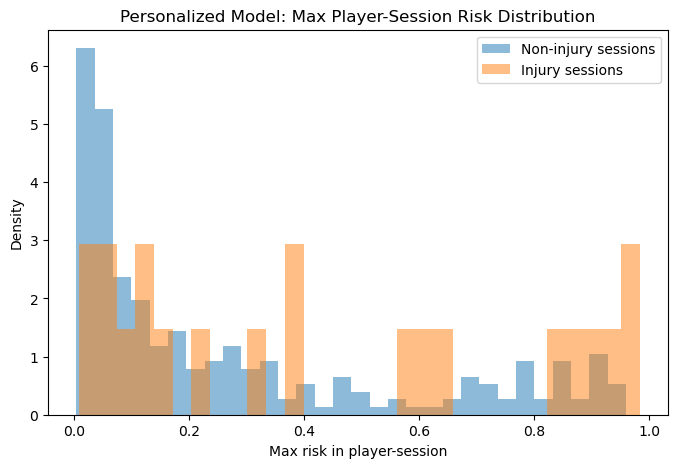

In [33]:
plt.figure(figsize=(8, 5))

for label, grp in session_risk.groupby("injury"):

    name = "Injury sessions" if label == 1 else "Non-injury sessions"

    plt.hist(
        grp["injury_risk"],
        bins=30,
        alpha=0.5,
        density=True,
        label=name
    )

plt.xlabel("Max risk in player-session")
plt.ylabel("Density")
plt.title("Personalized Model: Max Player-Session Risk Distribution")
plt.legend()
plt.show()

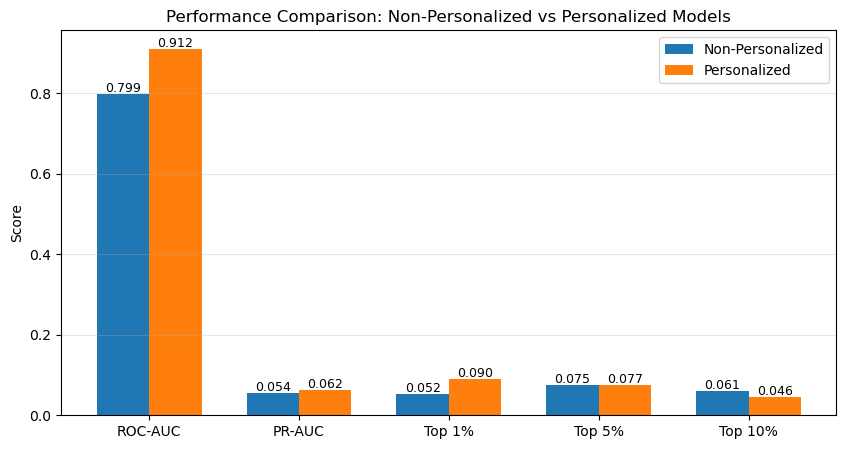

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# Comparative Performance Plot
# Non-Personalized vs Personalized
# ============================================

metrics = [
    "ROC-AUC",
    "PR-AUC",
    "Top 1%",
    "Top 5%",
    "Top 10%"
]

non_personalized = [
    0.7993272754355314,
    0.05442050865904267,
    0.052132701421800945,
    0.07451847173981686,
    0.061414587938111775
]

personalized = [
    0.9115002067085197,
    0.06232595521645803,
    0.08958837772397095,
    0.07650590741816773,
    0.04600038737168313
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width/2,
    non_personalized,
    width,
    label="Non-Personalized"
)

plt.bar(
    x + width/2,
    personalized,
    width,
    label="Personalized"
)

plt.xticks(x, metrics)

plt.ylabel("Score")

plt.title(
    "Performance Comparison: Non-Personalized vs Personalized Models"
)

plt.legend()

plt.grid(axis="y", alpha=0.3)

# value labels
for i, v in enumerate(non_personalized):
    plt.text(
        i - width/2,
        v + 0.005,
        f"{v:.3f}",
        ha="center",
        fontsize=9
    )

for i, v in enumerate(personalized):
    plt.text(
        i + width/2,
        v + 0.005,
        f"{v:.3f}",
        ha="center",
        fontsize=9
    )

plt.show()

### Conclusions

The proposed dynamic injury-risk modelling framework demonstrated that meaningful injury-associated temporal patterns can be identified throughout football training sessions using continuously updated physiological and biomechanical information. In the non-personalized setting, the model achieved a ROC-AUC of approximately 0.80 and a PR-AUC of approximately 0.054, indicating that even without athlete-specific normalization, the framework was capable of discriminating between injury-associated and non-injury sessions substantially better than random chance despite the severe class imbalance and the noisy nature of minute-level monitoring data. The temporal risk evolution analysis revealed that sessions which eventually resulted in injury consistently exhibited elevated predicted risk trajectories across the session duration compared to non-injury sessions, suggesting the presence of distinguishable dynamic workload and physiological patterns associated with injury-related states. Furthermore, the session-level maximal risk distributions demonstrated that injury-associated sessions tended to accumulate substantially higher maximal predicted risks, although with realistic overlap between classes, indicating that injury risk exists on a continuum rather than as a perfectly separable phenomenon. The personalized extension of the framework, which incorporated athlete-relative normalization through player-specific temporal baselines and z-score representations, further improved model discrimination and high-risk identification. Specifically, the personalized model achieved a ROC-AUC of approximately 0.91 and a PR-AUC of approximately 0.062, while nearly doubling the Top-1% enrichment rate from approximately 5.2% to approximately 9.0%. These findings suggest that deviations from an athlete’s own physiological and biomechanical baseline contain more informative injury-associated signal than absolute workload values alone. Importantly, the personalized framework did not simply increase predicted risk globally, but instead appeared to selectively amplify a subset of highly abnormal player-session states, as evidenced by the heavier right-tail distribution of maximal session risks observed in injury-associated sessions. Interestingly, while the personalized model substantially improved discrimination of the highest-risk observations, improvements in broader Top-5% and Top-10% enrichment were smaller, indicating that athlete-specific normalization may be particularly effective for identifying extreme-risk states rather than uniformly improving all risk strata. Overall, the findings support the hypothesis that dynamic temporal modelling combined with athlete-specific contextualization can improve the identification of injury-associated session states in elite football monitoring environments, while also highlighting the importance of longitudinal individualized modelling for future injury-risk assessment systems.

### Summary of Conclusions

In summary, the findings support the central research question of whether injury-associated session states can be dynamically estimated throughout a football session using only information available up to each minute t. Both the non-personalized and personalized frameworks demonstrated the ability to identify meaningful temporal risk patterns, while the personalized approach further improved the discrimination of high-risk observations by incorporating athlete-specific physiological context. Overall, the results suggest that continuously updated temporal monitoring, particularly when combined with individualized baselines, may provide a promising direction for dynamic injury-risk estimation in elite football environments.

In [35]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352287 entries, 0 to 352286
Data columns (total 83 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   session_id                       352287 non-null  object 
 1   minute_idx                       352287 non-null  int64  
 2   player_name                      352287 non-null  object 
 3   ctl28                            352287 non-null  float64
 4   ctl42                            352287 non-null  float64
 5   daily_load                       352287 non-null  float64
 6   weekly_load                      352287 non-null  float64
 7   acwr                             352287 non-null  float64
 8   monotony                         352287 non-null  float64
 9   strain                           352287 non-null  float64
 10  sleep_duration                   352287 non-null  float64
 11  sleep_quality                    352287 non-null  float64
 12  fa

In [36]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)

# Total observations
print(f"Minute-Level Observations: {len(model_df):,}")

# Athletes
if 'player_id' in model_df.columns:
    print(f"Athletes: {df['player_id'].nunique():,}")

# Sessions
if 'session_id' in model_df.columns:
    print(f"Sessions: {model_df['session_id'].nunique():,}")

# Target distribution
target_col = "injury"  # CHANGE IF NEEDED

print("\nTarget Distribution:")
print(model_df[target_col].value_counts())

injury_obs = model_df[target_col].sum()
non_injury_obs = len(model_df) - injury_obs

print(f"\nInjury Observations: {injury_obs:,}")
print(f"Non-Injury Observations: {non_injury_obs:,}")
print(f"Injury Prevalence: {100 * injury_obs / len(model_df):.4f}%")

# Number of features
exclude_cols = [
    target_col,
    'player_id',
    'session_id'
]

feature_count = len(
    [c for c in model_df.columns if c not in exclude_cols]
)

print(f"\nMonitoring Variables / Features: {feature_count}")

print("\nColumns:")
print(model_df.columns.tolist())

DATASET SUMMARY
Minute-Level Observations: 352,287
Sessions: 239

Target Distribution:
0    349513
1      2774
Name: injury, dtype: int64

Injury Observations: 2,774
Non-Injury Observations: 349,513
Injury Prevalence: 0.7874%

Monitoring Variables / Features: 81

Columns:
['session_id', 'minute_idx', 'player_name', 'ctl28', 'ctl42', 'daily_load', 'weekly_load', 'acwr', 'monotony', 'strain', 'sleep_duration', 'sleep_quality', 'fatigue', 'mood', 'readiness', 'soreness', 'stress', 'speed_mean_cum_mean', 'speed_mean_cum_max', 'speed_mean_cum_std', 'heart_rate_mean_cum_mean', 'heart_rate_mean_cum_max', 'heart_rate_mean_cum_std', 'hacc_mean_cum_mean', 'hacc_mean_cum_max', 'hacc_mean_cum_std', 'inst_acc_impulse_mean_cum_mean', 'inst_acc_impulse_mean_cum_max', 'inst_acc_impulse_mean_cum_std', 'accl_x_std_cum_mean', 'accl_x_std_cum_max', 'accl_x_std_cum_std', 'accl_y_std_cum_mean', 'accl_y_std_cum_max', 'accl_y_std_cum_std', 'accl_z_std_cum_mean', 'accl_z_std_cum_max', 'accl_z_std_cum_std', 'gy